# Experiment 1: Zero-Shot Prompt Engineering

**Method:** Ask the model to classify code without any training or examples.



---


# STEP 1: Check GPU


In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU required! Enable GPU in Kaggle settings.")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
Memory: 15.8 GB


# STEP 2: Install packages

In [2]:

!pip install -q bitsandbytes accelerate

# Verify installation
import bitsandbytes
print("Packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 35.6 MB/s eta 0:00:0000:0100:01
ERROR: pip's depe

# STEP 3: Imports

In [3]:
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login

warnings.filterwarnings('ignore')
print("Imports done!")

Imports done!


# STEP 4: HuggingFace Login

In [4]:
# Get token from Kaggle secrets
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("Logged in to HuggingFace!")

Logged in to HuggingFace!


# STEP 5: Load Dataset

In [5]:
# Find the JSON file
json_files = glob.glob('/kaggle/input/**/*.json', recursive=True)
print(f"Found files: {json_files}")

# Load the dataset
dataset = None
for f in json_files:
    with open(f, 'r') as file:
        data = json.load(file)
    if isinstance(data, list) and len(data) > 100:
        dataset = data
        print(f"Loaded: {f}")
        print(f"Samples: {len(dataset)}")
        break

if dataset is None:
    raise FileNotFoundError("Dataset not found!")

Found files: ['/kaggle/input/solana-dataset/solana_182_final.json']
Loaded: /kaggle/input/solana-dataset/solana_182_final.json
Samples: 182


# STEP 6: Split Dataset (80%/10%/10%)

In [6]:
# Group by vulnerability type for stratified split
by_type = defaultdict(list)
for sample in dataset:
    by_type[sample['vulnerability_type']].append(sample)

train_data, val_data, test_data = [], [], []

for vtype, samples in by_type.items():
    labels = [s['label'] for s in samples]
    # 80% train, 20% temp
    train_s, temp_s = train_test_split(samples, test_size=0.2, stratify=labels, random_state=42)
    # Split temp into 50% val, 50% test
    temp_labels = [s['label'] for s in temp_s]
    val_s, test_s = train_test_split(temp_s, test_size=0.5, stratify=temp_labels, random_state=42)
    
    train_data.extend(train_s)
    val_data.extend(val_s)
    test_data.extend(test_s)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print(f"Test labels: {Counter(s['label'] for s in test_data)}")

Train: 140 | Val: 21 | Test: 21
Test labels: Counter({'SAFE': 14, 'VULNERABLE': 7})


# STEP 7: Load Model (4-bit quantized)

In [7]:
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading model... (2-3 minutes)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN
)
model.eval()

print(f"Model loaded: {MODEL_ID}")

Loading model... (2-3 minutes)


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded: meta-llama/Llama-3.1-8B-Instruct


# STEP 8: Extract Code from Sample

In [8]:
def extract_code(sample):
    """Extract the code portion from a sample."""
    text = sample.get('text', '')
    
    # Find code between user header and assistant header
    if '<|start_header_id|>user<|end_header_id|>' in text:
        start = text.find('<|start_header_id|>user<|end_header_id|>') + len('<|start_header_id|>user<|end_header_id|>')
        end = text.find('<|eot_id|><|start_header_id|>assistant')
        if end > start:
            code = text[start:end].strip()
            # Remove markdown code blocks
            code = code.replace('```rust', '').replace('```', '').strip()
            return code
    
    # Fallback
    return sample.get('code', text[:1500])

# Test
test_code = extract_code(test_data[0])
print(f"Code length: {len(test_code)} chars")
print(f"First 200 chars: {test_code[:200]}...")

Code length: 705 chars
First 200 chars: pub fn process_swap(
    program_id: &Pubkey,
    amount_in: u64,
    minimum_amount_out: u64,
    accounts: &[AccountInfo],
) -> ProgramResult {
    let actual_amount_in = {
        if let Ok(transfe...


# STEP 9: Zero-Shot Prediction Function

In [9]:
def predict_zero_shot(sample):
    """Classify code as VULNERABLE or SAFE using zero-shot prompting."""
    code = extract_code(sample)
    
    # Simple, clear prompt
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a Solana smart contract security auditor.
Analyze the code and respond with exactly one word: VULNERABLE or SAFE.<|eot_id|><|start_header_id|>user<|end_header_id|>

```rust
{code[:1000]}
```

Is this code VULNERABLE or SAFE?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""
    
    # Tokenize
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # Decode only the new tokens
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    response = response.strip().upper()
    
    # Parse response
    if 'VULNERABLE' in response:
        return 'VULNERABLE'
    elif 'SAFE' in response:
        return 'SAFE'
    else:
        return 'VULNERABLE'  # Default to conservative

# Test on one sample
test_sample = test_data[0]
pred = predict_zero_shot(test_sample)
print(f"Prediction: {pred}")
print(f"Actual: {test_sample['label']}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prediction: VULNERABLE
Actual: SAFE


# STEP 10: Run Evaluation on Test Set

In [10]:
print("Running evaluation...")
print(f"Test samples: {len(test_data)}")
print("-" * 40)

results = []
for i, sample in enumerate(tqdm(test_data, desc="Evaluating")):
    pred = predict_zero_shot(sample)
    results.append({
        'vulnerability_type': sample['vulnerability_type'],
        'ground_truth': sample['label'],
        'prediction': pred,
        'correct': sample['label'] == pred
    })

print(f"\nDone! Correct: {sum(r['correct'] for r in results)}/{len(results)}")

Running evaluation...
Test samples: 21
----------------------------------------


Evaluating: 100%|██████████| 21/21 [00:24<00:00,  1.17s/it]


Done! Correct: 8/21


# STEP 11: Show Detailed Results

In [11]:
print("\nDetailed Results:")
print("-" * 60)
for i, r in enumerate(results, 1):
    status = "✓" if r['correct'] else "✗"
    print(f"{i:2}. {r['vulnerability_type']:<18} True: {r['ground_truth']:<12} Pred: {r['prediction']:<12} {status}")
print("-" * 60)


Detailed Results:
------------------------------------------------------------
 1. Integer Flow       True: SAFE         Pred: VULNERABLE   ✗
 2. Integer Flow       True: SAFE         Pred: SAFE         ✓
 3. Integer Flow       True: VULNERABLE   Pred: VULNERABLE   ✓
 4. Type Confusion     True: SAFE         Pred: VULNERABLE   ✗
 5. Type Confusion     True: SAFE         Pred: VULNERABLE   ✗
 6. Type Confusion     True: VULNERABLE   Pred: VULNERABLE   ✓
 7. DoS                True: SAFE         Pred: VULNERABLE   ✗
 8. DoS                True: SAFE         Pred: VULNERABLE   ✗
 9. DoS                True: VULNERABLE   Pred: VULNERABLE   ✓
10. Bump Seed          True: SAFE         Pred: VULNERABLE   ✗
11. Bump Seed          True: SAFE         Pred: VULNERABLE   ✗
12. Bump Seed          True: VULNERABLE   Pred: VULNERABLE   ✓
13. Unchecked Calls    True: SAFE         Pred: VULNERABLE   ✗
14. Unchecked Calls    True: SAFE         Pred: VULNERABLE   ✗
15. Unchecked Calls    True: VULNERABL

# STEP 12: Calculate Metrics

In [12]:
all_gt = [r['ground_truth'] for r in results]
all_pred = [r['prediction'] for r in results]

# Overall metrics
accuracy = accuracy_score(all_gt, all_pred)
precision = precision_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
recall = recall_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
f1 = f1_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)

print("=" * 50)
print("EXPERIMENT 1: ZERO-SHOT RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("=" * 50)

EXPERIMENT 1: ZERO-SHOT RESULTS
Accuracy:  38.10%
Precision: 35.00%
Recall:    100.00%
F1-Score:  51.85%


# STEP 13: Per-Vulnerability Metrics

In [13]:
print("\nPer-Vulnerability Type Performance:")
print("-" * 60)

metrics_by_type = {}
for vtype in sorted(set(r['vulnerability_type'] for r in results)):
    type_results = [r for r in results if r['vulnerability_type'] == vtype]
    gt = [r['ground_truth'] for r in type_results]
    pred = [r['prediction'] for r in type_results]
    
    acc = accuracy_score(gt, pred)
    metrics_by_type[vtype] = {'accuracy': acc, 'count': len(type_results)}
    print(f"{vtype:<20}: {acc:.2%} ({len(type_results)} samples)")

print("-" * 60)
print(f"{'AVERAGE':<20}: {np.mean([m['accuracy'] for m in metrics_by_type.values()]):.2%}")


Per-Vulnerability Type Performance:
------------------------------------------------------------
Bump Seed           : 33.33% (3 samples)
CPI                 : 33.33% (3 samples)
DoS                 : 33.33% (3 samples)
Integer Flow        : 66.67% (3 samples)
Missing Key Check   : 33.33% (3 samples)
Type Confusion      : 33.33% (3 samples)
Unchecked Calls     : 33.33% (3 samples)
------------------------------------------------------------
AVERAGE             : 38.10%


# STEP 14: Confusion Matrix

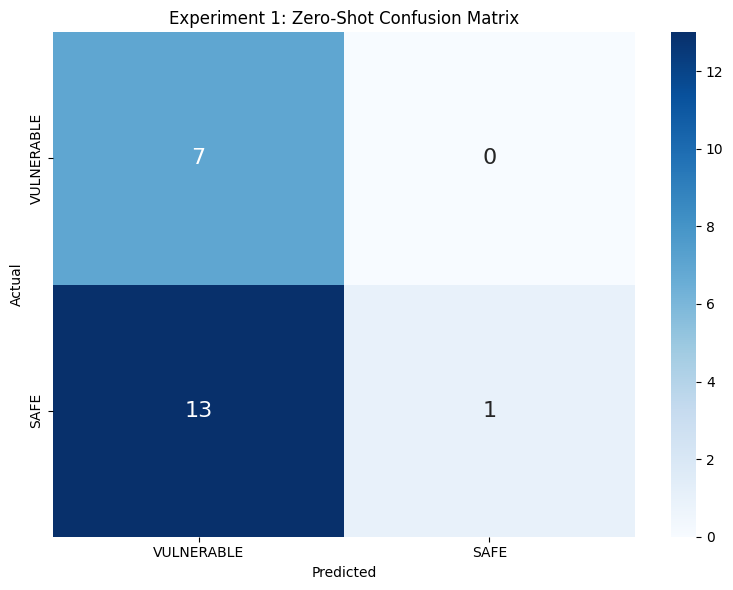


TP: 7 | FN: 0
FP: 13 | TN: 1


In [14]:
cm = confusion_matrix(all_gt, all_pred, labels=['VULNERABLE', 'SAFE'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['VULNERABLE', 'SAFE'],
            yticklabels=['VULNERABLE', 'SAFE'],
            annot_kws={'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Experiment 1: Zero-Shot Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_zero_shot.png', dpi=150)
plt.show()

print(f"\nTP: {cm[0,0]} | FN: {cm[0,1]}")
print(f"FP: {cm[1,0]} | TN: {cm[1,1]}")

# STEP 15: Save Results

In [15]:
# Save CSV
pd.DataFrame(results).to_csv('/kaggle/working/results_zero_shot.csv', index=False)

# Save JSON summary
summary = {
    'experiment': 'Zero-Shot Prompt Engineering',
    'model': MODEL_ID,
    'dataset_size': len(dataset),
    'test_size': len(test_data),
    'results': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    },
    'confusion_matrix': {
        'TP': int(cm[0,0]), 'FN': int(cm[0,1]),
        'FP': int(cm[1,0]), 'TN': int(cm[1,1])
    },
    'per_vulnerability': metrics_by_type
}

with open('/kaggle/working/summary_zero_shot.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  - results_zero_shot.csv")
print("  - summary_zero_shot.json")
print("  - cm_zero_shot.png")

Saved:
  - results_zero_shot.csv
  - summary_zero_shot.json
  - cm_zero_shot.png


# FINAL SUMMARY

In [16]:
print("\n" + "=" * 50)
print("EXPERIMENT 1 COMPLETE")
print("=" * 50)
print(f"\nMethod: Zero-Shot (no training, no examples)")
print(f"Model: {MODEL_ID}")
print(f"\nResults:")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  F1-Score: {f1:.2%}")
print(f"\nThis is the BASELINE. Fine-tuning should improve these results.")
print("=" * 50)


EXPERIMENT 1 COMPLETE

Method: Zero-Shot (no training, no examples)
Model: meta-llama/Llama-3.1-8B-Instruct

Results:
  Accuracy: 38.10%
  F1-Score: 51.85%

This is the BASELINE. Fine-tuning should improve these results.
